In [1]:
# ── Imports ─────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon, FancyArrowPatch
from matplotlib.collections import PatchCollection
from scipy.linalg import expm
from scipy.optimize import minimize
from scipy.spatial import ConvexHull
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── Wong colour palette (colorblind-safe, Nature/Science standard) ──────────
C = {
    'pareto':      '#E69F00',
    'ssa':         '#0072B2',
    'discord_ub':  '#D55E00',
    'chide_lb':    '#009E73',
    'dpi':         '#555555',   # darker grey for better visibility
    'dpi_fill':    '#AAAAAA',   # fill colour for DPI box
    'cloud':       '#56B4E9',
    'hull':        '#DDEEFF',
    'chide_zone':  '#D5F0E8',
    'buscemi':     '#CC79A7',
    'hidden_warn': '#F0E442',
}

CM = 1 / 2.54
FIG = {
    'full_2x2': (26*CM, 22*CM),
    'half_2x1': (26*CM, 12*CM),
    'wide_1x2': (26*CM, 10*CM),
    'wide_1x3': (36*CM, 10*CM),
    'single':   (13*CM, 11*CM),
}

plt.rcParams.update({
    'font.family':                    'serif',
    'font.size':                      8,
    'axes.spines.top':                True,
    'axes.spines.right':              True,
    'axes.grid':                      True,
    'grid.alpha':                     0.18,
    'figure.constrained_layout.use':  True,
    'figure.dpi':                     120,
})

def add_panel_labels(axes):
    for i, ax in enumerate(np.array(axes).flat):
        ax.text(-0.13, 1.04, f'({chr(97+i)})',
                transform=ax.transAxes,
                fontsize=9, fontweight='bold', va='bottom')

def save_figure(fig, basename):
    fig.savefig(f'{basename}.pdf', dpi=300)
    fig.savefig(f'{basename}.png', dpi=300)
    print(f'  Saved {basename}.pdf / .png')

# ── NEW: DPI box drawing helper ──────────────────────────────────────────────
def draw_dpi_box(ax, I_RA, label=True):
    """
    Draw the DPI feasibility box 0 ≤ x ≤ I(R:A), 0 ≤ y ≤ I(R:A)
    as a clearly visible filled rectangle with a bold border.

    The box is the hard constraint from the data-processing inequality:
    no channel can increase mutual information, so both I(R:B) and I(R:E)
    are bounded above by I(R:A).
    """
    if I_RA < 1e-6:
        return
    # Shaded interior (drawn first, behind everything)
    rect = mpatches.FancyBboxPatch(
        (0, 0), I_RA, I_RA,
        boxstyle="square,pad=0",
        facecolor=C['dpi_fill'], edgecolor='none',
        alpha=0.13, zorder=0, linewidth=0,
    )
    ax.add_patch(rect)
    # Bold border lines along top and right edges of the box
    ax.plot([0, I_RA], [I_RA, I_RA],           # top edge   y = I(R:A)
            color=C['dpi'], lw=2.0, linestyle='-',
            solid_capstyle='round', zorder=5)
    ax.plot([I_RA, I_RA], [0, I_RA],           # right edge  x = I(R:A)
            color=C['dpi'], lw=2.0, linestyle='-',
            solid_capstyle='round', zorder=5)
    # Corner marker
    ax.plot(I_RA, I_RA, marker='s', ms=6,
            color=C['dpi'], zorder=6, markeredgewidth=0)
    # Axis-aligned tick annotations
    ax.annotate('', xy=(I_RA, -0.001), xytext=(0, -0.001),
                xycoords='data', textcoords='data',
                arrowprops=dict(arrowstyle='<->', color=C['dpi'],
                                lw=1.2, shrinkA=0, shrinkB=0),
                annotation_clip=False)
    ax.annotate('', xy=(-0.001, I_RA), xytext=(-0.001, 0),
                xycoords='data', textcoords='data',
                arrowprops=dict(arrowstyle='<->', color=C['dpi'],
                                lw=1.2, shrinkA=0, shrinkB=0),
                annotation_clip=False)
    if label:
        # legend proxy only — actual label added in legend call
        pass

print('Cell 1 done — style, helpers, and draw_dpi_box loaded.')

Cell 1 done — style, helpers, and draw_dpi_box loaded.


In [2]:
# ── Pauli matrices ──────────────────────────────────────────────────────────
I2 = np.eye(2, dtype=complex)
X  = np.array([[0,1],[1,0]],    dtype=complex)
Y  = np.array([[0,-1j],[1j,0]], dtype=complex)
Z  = np.array([[1,0],[0,-1]],   dtype=complex)

def partial_trace(rho, keep, dims):
    n       = len(dims)
    current = rho.reshape(dims + dims)
    rem     = list(dims)
    for ax in sorted([i for i in range(n) if i not in keep], reverse=True):
        current = np.trace(current, axis1=ax, axis2=ax + len(rem))
        rem.pop(ax)
    kept = [dims[i] for i in sorted(keep)]
    d    = int(np.prod(kept))
    return current.reshape(d, d)

def S(rho):
    evals = np.linalg.eigvalsh(rho).real
    evals = evals[evals > 1e-15]
    return float(-np.sum(evals * np.log2(evals))) if len(evals) else 0.0

def MI(rho_AB, rho_A, rho_B):
    return max(0.0, S(rho_A) + S(rho_B) - S(rho_AB))

def ket_to_dm(psi):
    psi = np.asarray(psi, dtype=complex)
    psi = psi / np.linalg.norm(psi)
    return np.outer(psi, psi.conj())

ket0  = np.array([1,0], dtype=complex)
ket1  = np.array([0,1], dtype=complex)
ket_p = (ket0 + ket1) / np.sqrt(2)
ket_m = (ket0 - ket1) / np.sqrt(2)
dm0, dm1, dm_p, dm_m = [ket_to_dm(k) for k in (ket0, ket1, ket_p, ket_m)]

dm_phi_plus  = ket_to_dm([1, 0, 0,  1])
dm_phi_minus = ket_to_dm([1, 0, 0, -1])
dm_psi_plus  = ket_to_dm([0, 1, 1,  0])
dm_psi_minus = ket_to_dm([0, 1,-1,  0])

def werner(p):
    return p * dm_phi_plus + (1-p)/4 * np.eye(4, dtype=complex)

def depolarised(rho, p):
    return (1-p)*rho + p*np.eye(4, dtype=complex)/4

def dephasing_channel(rho_RA, p):
    ZZ = np.kron(I2, Z)
    return (1-p)*rho_RA + p*(ZZ @ rho_RA @ ZZ.conj().T)

def amplitude_damping_channel(rho_RA, gamma):
    K0 = np.array([[1,0],[0,np.sqrt(1-gamma)]], dtype=complex)
    K1 = np.array([[0,np.sqrt(gamma)],[0,0]],   dtype=complex)
    out = np.zeros((4,4), dtype=complex)
    for K in (K0, K1):
        M = np.kron(I2, K)
        out += M @ rho_RA @ M.conj().T
    return out

def bit_flip_channel(rho_RA, p):
    XX = np.kron(I2, X)
    return (1-p)*rho_RA + p*(XX @ rho_RA @ XX.conj().T)

def sep_cq(p1, rhoR1, phiA1, p2, rhoR2, phiA2):
    dmR1 = ket_to_dm(rhoR1) if rhoR1.ndim == 1 else rhoR1
    dmR2 = ket_to_dm(rhoR2) if rhoR2.ndim == 1 else rhoR2
    return p1*np.kron(dmR1, ket_to_dm(phiA1)) + p2*np.kron(dmR2, ket_to_dm(phiA2))

def bell_mixture(p):
    return p * dm_phi_plus + (1 - p) * dm_phi_minus

def has_hidden_environment(rho_RA, eps=1e-4):
    rho_R = partial_trace(rho_RA, [0], [2,2])
    S_RA  = S(rho_RA)
    return S_RA > eps and S_RA < S(rho_R) - eps

print('Cell 2 done — quantum utilities loaded.')

Cell 2 done — quantum utilities loaded.


In [3]:
# ── KAK (Cartan) decomposition of SU(4) ────────────────────────────────────
def _su2_zyz(a, b, c):
    Rz = lambda t: np.array([[np.exp(-.5j*t), 0],
                              [0, np.exp(.5j*t)]], dtype=complex)
    Ry = lambda t: np.array([[np.cos(t/2), -np.sin(t/2)],
                              [np.sin(t/2),  np.cos(t/2)]], dtype=complex)
    return Rz(a) @ Ry(b) @ Rz(c)

def build_u4_kak(params):
    c1, c2, c3 = params[0], params[1], params[2]
    Omega = expm(1j*(c1*np.kron(X,X) + c2*np.kron(Y,Y) + c3*np.kron(Z,Z)))
    A1 = _su2_zyz(*params[9:12])
    A2 = _su2_zyz(*params[12:15])
    A3 = _su2_zyz(*params[3:6])
    A4 = _su2_zyz(*params[6:9])
    return np.kron(A1, A2) @ Omega @ np.kron(A3, A4)

def random_kak_params(rng=None):
    if rng is None:
        rng = np.random.default_rng()
    params    = rng.uniform(-np.pi, np.pi, 15)
    c         = np.sort(rng.uniform(0, np.pi/4, 3))[::-1]
    c[2]      = c[2] * rng.choice([-1, 1])
    params[:3] = c
    return params

def compute_IB_IE(rho_RA, U):
    rho_RAE = np.kron(rho_RA, dm0)
    U_full  = np.kron(I2, U)
    sigma   = U_full @ rho_RAE @ U_full.conj().T
    d3      = [2, 2, 2]
    sR  = partial_trace(sigma, [0],    d3)
    sB  = partial_trace(sigma, [1],    d3)
    sE  = partial_trace(sigma, [2],    d3)
    sRB = partial_trace(sigma, [0, 1], d3)
    sRE = partial_trace(sigma, [0, 2], d3)
    return (max(0.0, MI(sRB, sR, sB)),
            max(0.0, MI(sRE, sR, sE)))

print('Cell 3 done — KAK decomposition loaded.')

Cell 3 done — KAK decomposition loaded.


In [4]:
# ── Quantum discord ─────────────────────────────────────────────────────────
def _classical_mi(rho_RA, theta, phi, measure_on_A=True):
    c, s = np.cos(theta/2), np.sin(theta/2)*np.exp(1j*phi)
    Pi0  = np.outer([c,s], [c.conj(), s.conj()])
    Pi1  = I2 - Pi0
    keep_sys = 0 if measure_on_A else 1
    FP = (lambda P: np.kron(I2, P)) if measure_on_A else (lambda P: np.kron(P, I2))
    marg = partial_trace(rho_RA, [keep_sys], [2, 2])
    S_marg = S(marg)
    cond = 0.0
    for Pi in (Pi0, Pi1):
        M  = FP(Pi) @ rho_RA @ FP(Pi).conj().T
        pk = np.real(np.trace(M))
        if pk > 1e-12:
            rho_cond = partial_trace(M/pk, [keep_sys], [2, 2])
            cond += pk * S(rho_cond)
    return max(0.0, S_marg - cond)

def quantum_discord(rho_RA, measure_on_A=True, n_grid=25, n_restarts=10):
    d2    = [2, 2]
    rho_R = partial_trace(rho_RA, [0], d2)
    rho_A = partial_trace(rho_RA, [1], d2)
    I_RA  = MI(rho_RA, rho_R, rho_A)

    def neg_cmi(x):
        return -_classical_mi(rho_RA, x[0], x[1], measure_on_A)

    best_val, best_x = -np.inf, [0.0, 0.0]
    for th in np.linspace(0, np.pi, n_grid):
        for ph in np.linspace(0, 2*np.pi, n_grid):
            v = _classical_mi(rho_RA, th, ph, measure_on_A)
            if v > best_val:
                best_val, best_x = v, [th, ph]

    target = rho_A if measure_on_A else rho_R
    _, evecs = np.linalg.eigh(target)
    seeds = [best_x]
    for vec in evecs.T:
        th_e = 2*np.arccos(np.clip(np.abs(vec[0]), 0, 1))
        ph_e = (np.angle(vec[1]) - np.angle(vec[0])) if np.abs(vec[0]) > 1e-9 else 0.0
        seeds.append([th_e % np.pi, ph_e % (2*np.pi)])

    rng = np.random.default_rng(0)
    for _ in range(n_restarts):
        seeds.append([rng.uniform(0, np.pi), rng.uniform(0, 2*np.pi)])

    best_cmi = best_val
    for x0 in seeds:
        res = minimize(neg_cmi, x0, method='L-BFGS-B',
                       bounds=[(0, np.pi), (0, 2*np.pi)],
                       options={'maxiter': 400, 'ftol': 1e-14})
        if -res.fun > best_cmi:
            best_cmi = -res.fun

    return max(0.0, I_RA - best_cmi)

print('Cell 4 done — quantum discord loaded.')

Cell 4 done — quantum discord loaded.


In [5]:
# ── Analytical bounds ────────────────────────────────────────────────────────
def coherent_information(rho_RA):
    d2    = [2, 2]
    rho_R = partial_trace(rho_RA, [0], d2)
    return max(0.0, S(rho_R) - S(rho_RA))

def compute_state_info(rho_RA, verbose=False):
    d2    = [2, 2]
    rho_R = partial_trace(rho_RA, [0], d2)
    rho_A = partial_trace(rho_RA, [1], d2)
    S_R   = max(0.0, S(rho_R))
    S_A   = max(0.0, S(rho_A))
    S_RA  = max(0.0, S(rho_RA))
    I_RA  = max(0.0, MI(rho_RA, rho_R, rho_A))
    I_c   = max(0.0, S_R - S_RA)
    D_RgA = max(0.0, quantum_discord(rho_RA, measure_on_A=True))
    D_AgR = max(0.0, quantum_discord(rho_RA, measure_on_A=False))
    min_D = min(D_RgA, D_AgR)
    gap   = abs(I_RA - 2*min_D)
    info  = dict(
        S_R        = S_R,
        S_A        = S_A,
        S_RA       = S_RA,
        I_RA       = I_RA,
        I_c        = I_c,
        D_RgA      = D_RgA,
        D_AgR      = D_AgR,
        min_D      = min_D,
        SSA_upper  = max(0.0, S_R + 2.0 - S_RA),
        discord_ub = max(0.0, I_RA + gap),
        C_hide_lb  = max(0.0, I_RA - gap),
        buscemi_lb = 2.0 * I_c,
        hidden_env = has_hidden_environment(rho_RA),
    )
    if verbose:
        print(f"  S(R)={S_R:.4f}  S(RA)={S_RA:.4f}  I(R:A)={I_RA:.4f}")
        print(f"  I_c(A→R) = {I_c:.4f}  →  Buscemi LB = 2·I_c = {2*I_c:.4f}  [exact]")
        print(f"  D(R|A)={D_RgA:.4f}  D(A|R)={D_AgR:.4f}  min_D={min_D:.4f}")
        print(f"  SSA_upper  = {info['SSA_upper']:.4f}  [exact]")
        print(f"  discord_ub = {info['discord_ub']:.4f}  [conjecture]")
        print(f"  C_hide_lb  = {info['C_hide_lb']:.4f}  [conjecture]")
        print(f"  hidden_env = {info['hidden_env']}")
    return info

print('Cell 5 done — all analytical bounds loaded.')

Cell 5 done — all analytical bounds loaded.


In [6]:
# ── KAK sampling ─────────────────────────────────────────────────────────────
def sample_kak_isometries(rho_RA, n_samples=1500, seed=None):
    rng = np.random.default_rng(seed)
    pts = [compute_IB_IE(rho_RA, build_u4_kak(random_kak_params(rng)))
           for _ in range(n_samples)]
    return np.array(pts)

def _find_extreme_point(rho_RA, axis, n_restarts=40, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    best_val, best_params = 0.0, None
    for _ in range(n_restarts):
        x0  = random_kak_params(rng)
        res = minimize(
            lambda p: -compute_IB_IE(rho_RA, build_u4_kak(p))[axis],
            x0, method='L-BFGS-B',
            options={'maxiter': 5000, 'ftol': 1e-13})
        if -res.fun > best_val:
            best_val, best_params = -res.fun, res.x
    return max(0.0, best_val), best_params

def find_C_hide_numerical(rho_RA, n_restarts=40, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    best_val, best_pt = np.inf, (0.0, 0.0)
    for _ in range(n_restarts):
        res = minimize(
            lambda p: sum(compute_IB_IE(rho_RA, build_u4_kak(p))),
            random_kak_params(rng), method='L-BFGS-B',
            options={'maxiter': 5000, 'ftol': 1e-13})
        if res.fun < best_val:
            best_val = res.fun
            best_pt  = compute_IB_IE(rho_RA, build_u4_kak(res.x))
    return max(0.0, best_val), best_pt

def maximize_sum_IBE(rho_RA, n_restarts=40, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    best = 0.0
    for _ in range(n_restarts):
        res = minimize(
            lambda p: -sum(compute_IB_IE(rho_RA, build_u4_kak(p))),
            random_kak_params(rng), method='L-BFGS-B',
            options={'maxiter': 5000, 'ftol': 1e-13})
        if -res.fun > best:
            best = -res.fun
    return max(0.0, best)

def _pareto_filter(pts):
    pts = pts[np.argsort(pts[:, 0])]
    deduped = [pts[0]]
    for pt in pts[1:]:
        if np.linalg.norm(pt - deduped[-1]) > 1e-6:
            deduped.append(pt)
    pts = np.array(deduped)
    out = [pts[0]]
    for pt in pts[1:]:
        if pt[1] <= out[-1][1] + 1e-9:
            out.append(pt)
    return np.array(out)

def _minimize_one_axis(rho_RA, t, band, warm_x, n_restarts, rng, fix_axis):
    min_axis = 1 - fix_axis
    best_val = np.inf
    best_p   = None
    seeds    = ([warm_x] if warm_x is not None else []) + \
               [random_kak_params(rng) for _ in range(n_restarts)]
    for x0 in seeds:
        try:
            res = minimize(
                lambda p: compute_IB_IE(rho_RA, build_u4_kak(p))[min_axis],
                x0, method='SLSQP',
                constraints=[
                    {'type': 'ineq',
                     'fun': lambda p: compute_IB_IE(rho_RA, build_u4_kak(p))[fix_axis] - t},
                    {'type': 'ineq',
                     'fun': lambda p: t + band - compute_IB_IE(rho_RA, build_u4_kak(p))[fix_axis]},
                ],
                options={'maxiter': 600, 'ftol': 1e-11})
            IB, IE = compute_IB_IE(rho_RA, build_u4_kak(res.x))
            fixed_ok = (fix_axis == 0 and IB >= t - 0.03) or \
                       (fix_axis == 1 and IE >= t - 0.03)
            val = IE if min_axis == 1 else IB
            if fixed_ok and val < best_val:
                best_val = val
                best_p   = res.x
        except Exception:
            pass
    if best_p is None:
        return None
    IB, IE = compute_IB_IE(rho_RA, build_u4_kak(best_p))
    return IB, IE, best_p

def pareto_frontier(rho_RA, n_points=14, n_restarts=6,
                    n_extreme_restarts=40, seed=None):
    rng  = np.random.default_rng(seed)
    info = compute_state_info(rho_RA)

    IE_max, p_IE = _find_extreme_point(rho_RA, axis=1,
                                       n_restarts=n_extreme_restarts, rng=rng)
    IB_max, p_IB = _find_extreme_point(rho_RA, axis=0,
                                       n_restarts=n_extreme_restarts, rng=rng)
    print(f'    IE_max={IE_max:.4f}  IB_max={IB_max:.4f}')

    if IE_max < 1e-5 and IB_max < 1e-5:
        return np.array([[0.0, 0.0]])

    collected = []
    n1 = max(1, n_points // 3)
    n2 = n_points - n1

    IE_targets = np.concatenate([
        np.linspace(0.0, 0.3*IE_max, n1+1)[:-1],
        np.linspace(0.3*IE_max, IE_max, n2+1)
    ])
    band_IE = max(0.04, IE_max * 0.07)
    warm = p_IE
    for t in reversed(IE_targets):
        result = _minimize_one_axis(rho_RA, t, band_IE, warm,
                                    n_restarts, rng, fix_axis=1)
        if result is not None:
            IB, IE, warm = result
            collected.append((IB, IE))

    IB_targets = np.concatenate([
        np.linspace(0.0, 0.3*IB_max, n1+1)[:-1],
        np.linspace(0.3*IB_max, IB_max, n2+1)
    ])
    band_IB = max(0.04, IB_max * 0.07)
    warm = p_IB
    for t in reversed(IB_targets):
        result = _minimize_one_axis(rho_RA, t, band_IB, warm,
                                    n_restarts, rng, fix_axis=0)
        if result is not None:
            IB, IE, warm = result
            collected.append((IB, IE))

    collected.append((0.0, IE_max))
    collected.append((IB_max, 0.0))
    if info['C_hide_lb'] < 0.01:
        collected.append((0.0, 0.0))

    pts = np.array(collected)
    pts = pts[(pts[:, 0] >= -1e-3) & (pts[:, 1] >= -1e-3)]
    pts = np.clip(pts, 0, None)
    return _pareto_filter(pts)

def verify_bounds(frontier, info, tol=0.025):
    sums = frontier[:, 0] + frontier[:, 1]
    return dict(
        ssa_ok        = bool(np.all(sums <= info['SSA_upper']  + tol)),
        discord_ub_ok = bool(np.all(sums <= info['discord_ub'] + tol)),
        C_hide_lb_ok  = bool(np.all(sums >= info['C_hide_lb']  - tol)),
        dpi_ok        = bool(np.all(frontier[:, 0] <= info['I_RA'] + tol) and
                             np.all(frontier[:, 1] <= info['I_RA'] + tol)),
        buscemi_ok    = bool(np.all(sums >= info['buscemi_lb'] - tol)),
    )

print('Cell 6 done — Pareto frontier algorithms loaded.')

Cell 6 done — Pareto frontier algorithms loaded.


In [7]:
# ── draw_pareto_only ──────────────────────────────────────────────────────────
# NOW INCLUDES the visible DPI box in every panel.

def draw_pareto_only(ax, rho_RA, title,
                     n_samples=1500, n_pareto_points=14,
                     n_pareto_restarts=6, n_extreme_restarts=40,
                     seed=42, color=None, verbose=False):
    info     = compute_state_info(rho_RA, verbose=verbose)
    I_RA     = info['I_RA']
    col      = color if color is not None else C['pareto']

    print(f'  Sampling {n_samples} isometries...')
    pts = sample_kak_isometries(rho_RA, n_samples=n_samples, seed=seed)

    print(f'  Computing Pareto frontier...')
    frontier = pareto_frontier(rho_RA,
                               n_points=n_pareto_points,
                               n_restarts=n_pareto_restarts,
                               n_extreme_restarts=n_extreme_restarts,
                               seed=seed)

    p995 = np.percentile(pts, 99.5, axis=0) if len(pts) > 0 else [0, 0]
    lim  = max(p995[0], p995[1], I_RA, 0.15) * 1.18

    # ── z=0  DPI box (drawn first — behind everything) ───────────────────────
    # Box: 0 ≤ x ≤ I(R:A),  0 ≤ y ≤ I(R:A)
    draw_dpi_box(ax, I_RA)

    # ── z=0  diagonal reference ──────────────────────────────────────────────
    ax.plot([0, lim], [0, lim], color='#cccccc', lw=0.8,
            linestyle=':', zorder=0)

    # ── z=1  KAK cloud ───────────────────────────────────────────────────────
    ax.scatter(pts[:, 0], pts[:, 1],
               s=3, alpha=0.30, c=C['cloud'],
               rasterized=True, zorder=1)

    # ── z=2  convex hull fill ────────────────────────────────────────────────
    if len(pts) >= 4:
        try:
            hull  = ConvexHull(pts)
            hverts = pts[hull.vertices]
            poly  = Polygon(hverts, closed=True,
                            facecolor=C['hull'], edgecolor='none',
                            alpha=0.55, zorder=2)
            ax.add_patch(poly)
        except Exception:
            pass

    # ── z=6  Pareto frontier ─────────────────────────────────────────────────
    ax.plot(frontier[:, 0], frontier[:, 1],
            color=col, lw=2.2, marker='o', ms=4.5,
            zorder=6, label='Pareto frontier')

    ax.set_xlim(-0.02*lim, lim)
    ax.set_ylim(-0.02*lim, lim)
    ax.set_aspect('equal')
    ax.set_xlabel('$I(R:B)$ (bits)', fontsize=7)
    ax.set_ylabel('$I(R:E)$ (bits)', fontsize=7)
    ax.set_title(title, fontsize=8, pad=4)

    # Legend — include the DPI box proxy
    dpi_patch = mpatches.Patch(
        facecolor=C['dpi_fill'], edgecolor=C['dpi'],
        linewidth=1.5, alpha=0.5,
        label=f'DPI box: $0\\leq x,y\\leq I(R:A)={I_RA:.3f}$')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles + [dpi_patch],
              fontsize=6, loc='upper right', framealpha=0.9)

    info['frontier'] = frontier
    return info

print('Cell 7 done — draw_pareto_only (with DPI box) loaded.')

Cell 7 done — draw_pareto_only (with DPI box) loaded.


In [8]:
# ── draw_panel ────────────────────────────────────────────────────────────────
# Full panel with all five bounds + VISIBLE DPI box.

def draw_panel(ax, rho_RA, title,
               n_samples=1500, n_pareto_points=14,
               n_pareto_restarts=6, n_extreme_restarts=40,
               seed=42, verbose=False):
    info       = compute_state_info(rho_RA, verbose=verbose)
    I_RA       = info['I_RA']
    SSA        = info['SSA_upper']
    disc_ub    = info['discord_ub']
    chide_lb   = info['C_hide_lb']
    buscemi_lb = info['buscemi_lb']
    hidden_env = info['hidden_env']

    print(f'  Sampling {n_samples} isometries...')
    pts = sample_kak_isometries(rho_RA, n_samples=n_samples, seed=seed)

    print(f'  Computing Pareto frontier...')
    frontier = pareto_frontier(rho_RA,
                               n_points=n_pareto_points,
                               n_restarts=n_pareto_restarts,
                               n_extreme_restarts=n_extreme_restarts,
                               seed=seed)

    print(f'  Finding C_hide numerical minimum...')
    rng = np.random.default_rng(seed)
    C_hide_num, C_hide_pt = find_C_hide_numerical(rho_RA, n_restarts=40, rng=rng)

    p995 = np.percentile(pts, 99.5, axis=0) if len(pts) > 0 else [0, 0]
    lim  = max(
        p995[0], p995[1],
        I_RA,
        SSA      * 0.72,
        disc_ub  * 0.72,
        chide_lb  + 0.05,
        buscemi_lb + 0.05,
        0.15
    ) * 1.18

    xx = np.linspace(0.0, lim * 1.05, 500)

    # ── z=0a  DPI box — filled square, bold border ───────────────────────────
    # Box: 0 ≤ I(R:B) ≤ I(R:A)  AND  0 ≤ I(R:E) ≤ I(R:A)
    # Drawn FIRST so all other elements are visible on top of it.
    draw_dpi_box(ax, I_RA)

    # ── z=0b  diagonal reference ─────────────────────────────────────────────
    ax.plot([0, lim], [0, lim], color='#cccccc', lw=0.8,
            linestyle=':', zorder=0)

    # ── z=1  KAK cloud ───────────────────────────────────────────────────────
    ax.scatter(pts[:, 0], pts[:, 1],
               s=3, alpha=0.35, c=C['cloud'],
               rasterized=True, zorder=1)

    # ── z=2  convex hull fill ────────────────────────────────────────────────
    if len(pts) >= 4:
        try:
            hull   = ConvexHull(pts)
            hverts = pts[hull.vertices]
            poly   = Polygon(hverts, closed=True,
                             facecolor=C['hull'], edgecolor='none',
                             alpha=0.55, zorder=2)
            ax.add_patch(poly)
        except Exception:
            pass

    # ── z=3a  forbidden zone below C_hide LB ────────────────────────────────
    if chide_lb > 1e-4:
        xx_c = np.linspace(0.0, chide_lb, 500)
        yy_c = np.clip(chide_lb - xx_c, 0, lim)
        mask_c = (xx_c <= chide_lb) & (yy_c >= 0)
        if mask_c.any():
            ax.fill_between(xx_c[mask_c], 0, yy_c[mask_c],
                            color=C['chide_zone'], alpha=0.45, zorder=3)

    # ── z=3b  forbidden zone below Buscemi LB ───────────────────────────────
    if buscemi_lb > 1e-4:
        xx_b = np.linspace(0.0, buscemi_lb, 500)
        yy_b = np.clip(buscemi_lb - xx_b, 0, lim)
        mask_b = (xx_b <= buscemi_lb) & (yy_b >= 0)
        if mask_b.any():
            ax.fill_between(xx_b[mask_b], 0, yy_b[mask_b],
                            color=C['buscemi'], alpha=0.08, zorder=3)

    # ── z=4  bound lines ─────────────────────────────────────────────────────

    # SSA upper (exact)
    _x0 = max(0.0, SSA - lim*1.05); _x1 = min(SSA, lim*1.05)
    if _x1 >= _x0 - 1e-10:
        ax.plot([_x0, _x1], [SSA-_x0, SSA-_x1],
                color=C['ssa'], lw=1.8, linestyle='-', zorder=4,
                label=f'SSA (exact): $x+y\\leq{SSA:.3f}$')

    # Discord UB (conjecture)
    disc_color = C['hidden_warn'] if hidden_env else C['discord_ub']
    disc_label = ('Discord UB$^\\dagger$ (conj.)' if hidden_env
                  else 'Discord UB (conj.)') + \
                 f': $x+y\\leq{disc_ub:.3f}$'
    _x0 = max(0.0, disc_ub - lim*1.05); _x1 = min(disc_ub, lim*1.05)
    if _x1 >= _x0 - 1e-10:
        ax.plot([_x0, _x1], [disc_ub-_x0, disc_ub-_x1],
                color=disc_color, lw=1.8, linestyle='--', zorder=4,
                label=disc_label)

    # C_hide LB (conjecture)
    if chide_lb > 1e-4:
        _x0 = max(0.0, chide_lb - lim*1.05); _x1 = min(chide_lb, lim*1.05)
        if _x1 >= _x0 - 1e-10:
            ax.plot([_x0, _x1], [chide_lb-_x0, chide_lb-_x1],
                    color=C['chide_lb'], lw=1.8, linestyle='--', zorder=4,
                    label=f'$C_{{\\rm hide}}$ LB (conj.): $x+y\\geq{chide_lb:.3f}$')
    else:
        ax.plot([], [], color=C['chide_lb'], lw=1.8, linestyle='--',
                label=f'$C_{{\\rm hide}}$ LB (conj.) $={chide_lb:.3f}$ (trivial)')

    # Buscemi LB (exact)
    if buscemi_lb > 1e-4:
        _x0 = max(0.0, buscemi_lb - lim*1.05); _x1 = min(buscemi_lb, lim*1.05)
        if _x1 >= _x0 - 1e-10:
            ax.plot([_x0, _x1], [buscemi_lb-_x0, buscemi_lb-_x1],
                    color=C['buscemi'], lw=2.0, linestyle='-.', zorder=4,
                    label=f'Buscemi LB (exact): $x+y\\geq 2I_c={buscemi_lb:.3f}$')
    else:
        ax.plot([], [], color=C['buscemi'], lw=2.0, linestyle='-.',
                label=f'Buscemi LB (exact): $2I_c={buscemi_lb:.3f}$ (trivial)')

    # ── z=5  C_hide numerical diamond ────────────────────────────────────────
    ax.scatter(*C_hide_pt, marker='D', s=50, color=C['chide_lb'],
               zorder=5, edgecolors='k', linewidths=0.6,
               label=f'$C_{{\\rm hide}}^{{\\rm num}}={C_hide_num:.3f}$')
    ax.annotate(
        f'$({C_hide_pt[0]:.3f},\\,{C_hide_pt[1]:.3f})$',
        xy=C_hide_pt, xytext=(5, 5), textcoords='offset points',
        fontsize=5.5, color=C['chide_lb'], ha='left', va='bottom', zorder=7)

    # ── z=6  Pareto frontier ─────────────────────────────────────────────────
    ax.plot(frontier[:, 0], frontier[:, 1],
            color=C['pareto'], lw=2.0, marker='o', ms=4,
            zorder=6, label='Pareto frontier')

    if hidden_env:
        ax.text(0.02, 0.02, '$^\\dagger$ hidden env.',
                transform=ax.transAxes, fontsize=6,
                color=C['discord_ub'], va='bottom')

    ax.set_xlim(-0.02*lim, lim)
    ax.set_ylim(-0.02*lim, lim)
    ax.set_aspect('equal')
    ax.set_xlabel('$I(R:B)$ (bits)', fontsize=7)
    ax.set_ylabel('$I(R:E)$ (bits)', fontsize=7)
    ax.set_title(title, fontsize=8, pad=4)

    # Legend — add DPI box proxy
    dpi_patch = mpatches.Patch(
        facecolor=C['dpi_fill'], edgecolor=C['dpi'],
        linewidth=1.5, alpha=0.5,
        label=f'DPI box (exact): $0\\leq x,y\\leq I(R\\!:\\!A)={I_RA:.3f}$')
    handles, labels_leg = ax.get_legend_handles_labels()
    ax.legend(handles=handles + [dpi_patch],
              fontsize=5.2, loc='best', framealpha=0.9,
              handlelength=1.5, borderpad=0.5, ncol=1)

    info['C_hide_num'] = C_hide_num
    info['C_hide_pt']  = C_hide_pt
    info['frontier']   = frontier
    info['bounds_ok']  = verify_bounds(frontier, info)
    return info

print('Cell 8 done — draw_panel (with visible DPI box) loaded.')

Cell 8 done — draw_panel (with visible DPI box) loaded.



>>> Bell $|\Phi^+\rangle$ — pure, max entangled
  S(R)=1.0000  S(RA)=0.0000  I(R:A)=2.0000
  I_c(A→R) = 1.0000  →  Buscemi LB = 2·I_c = 2.0000  [exact]
  D(R|A)=1.0000  D(A|R)=1.0000  min_D=1.0000
  SSA_upper  = 3.0000  [exact]
  discord_ub = 2.0000  [conjecture]
  C_hide_lb  = 2.0000  [conjecture]
  hidden_env = False
  Sampling 1500 isometries...
  Computing Pareto frontier...
    IE_max=2.0000  IB_max=2.0000

>>> Werner $p=0.5$ — mixed entangled
  S(R)=1.0000  S(RA)=1.5488  I(R:A)=0.4512
  I_c(A→R) = 0.0000  →  Buscemi LB = 2·I_c = 0.0000  [exact]
  D(R|A)=0.2625  D(A|R)=0.2625  min_D=0.2625
  SSA_upper  = 1.4512  [exact]
  discord_ub = 0.5250  [conjecture]
  C_hide_lb  = 0.3774  [conjecture]
  hidden_env = False
  Sampling 1500 isometries...
  Computing Pareto frontier...
    IE_max=0.4512  IB_max=0.4512

>>> Werner $p=1/3$ — separability boundary
  S(R)=1.0000  S(RA)=1.7925  I(R:A)=0.2075
  I_c(A→R) = 0.0000  →  Buscemi LB = 2·I_c = 0.0000  [exact]
  D(R|A)=0.1258  D(A|R)=0.1258 

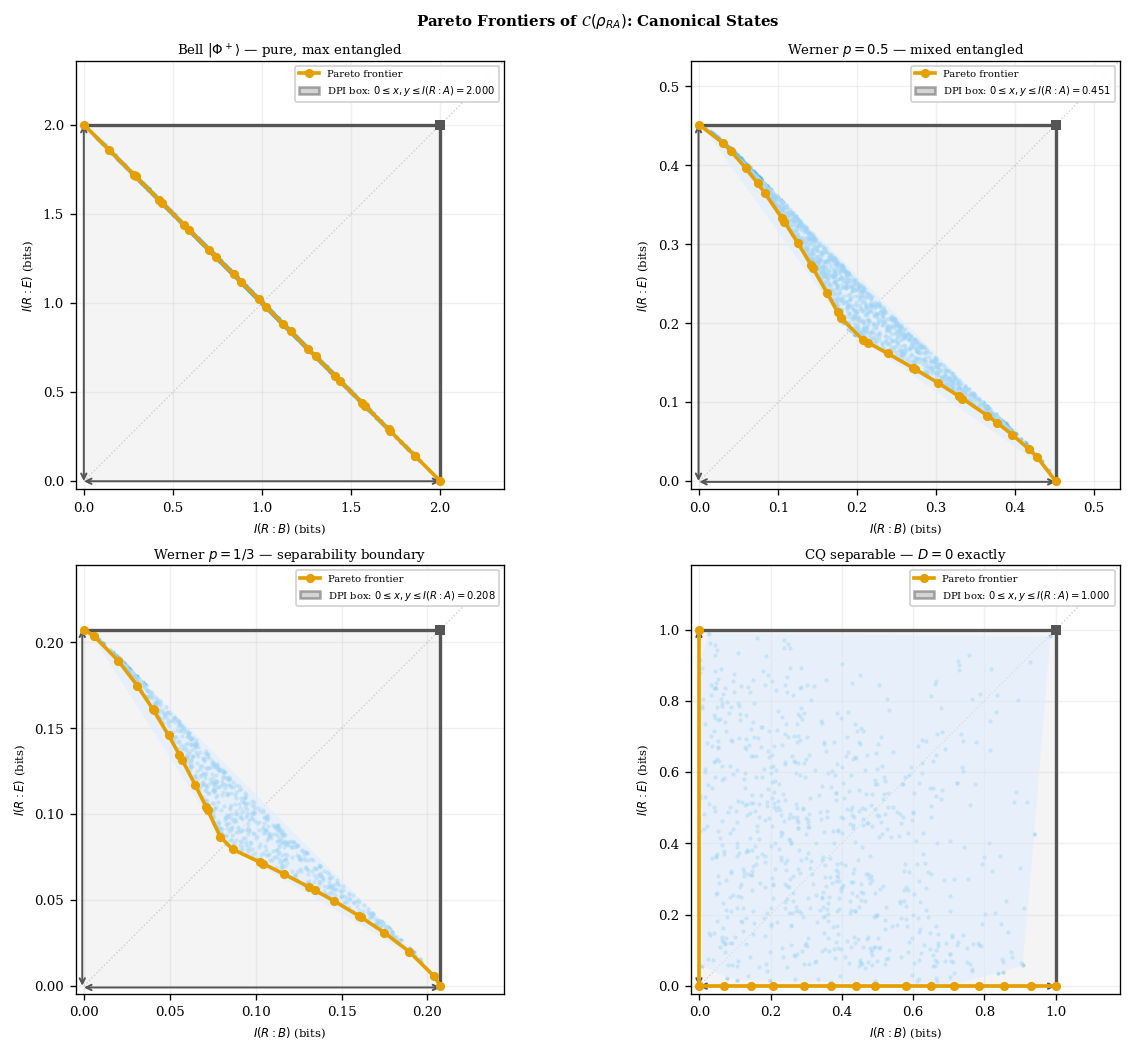

Part 1 · Figure 1 done.


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
#  PART 1 — PARETO FRONTIERS ONLY  (now with visible DPI box)
# ══════════════════════════════════════════════════════════════════════════════

cq_state = sep_cq(0.5, ket0, ket0, 0.5, ket1, ket1)

states_fig1 = [
    (dm_phi_plus,  r'Bell $|\Phi^+\rangle$ — pure, max entangled', 1500),
    (werner(0.5),  r'Werner $p=0.5$ — mixed entangled',            1500),
    (werner(1/3),  r'Werner $p=1/3$ — separability boundary',       800),
    (cq_state,     r'CQ separable — $D=0$ exactly',                  800),
]

fig1, axes1 = plt.subplots(2, 2, figsize=FIG['full_2x2'])
fig1.suptitle(
    r'Pareto Frontiers of $\mathcal{C}(\rho_{RA})$: Canonical States',
    fontsize=9, fontweight='bold')

results_p1_fig1 = []
for ax, (rho, name, nsamp) in zip(axes1.flat, states_fig1):
    print(f'\n>>> {name}')
    res = draw_pareto_only(ax, rho, name,
                           n_samples=nsamp,
                           n_pareto_points=14,
                           n_pareto_restarts=6,
                           n_extreme_restarts=40,
                           seed=42, verbose=True)
    results_p1_fig1.append(res)

#add_panel_labels(axes1)
save_figure(fig1, 'p1_fig1_canonical_frontiers')
plt.show()
print('Part 1 · Figure 1 done.')


>>> Werner p=0.000
    IE_max=0.0000  IB_max=0.0000

>>> Werner p=0.200
    IE_max=0.0781  IB_max=0.0781

>>> Werner p=0.333
    IE_max=0.2075  IB_max=0.2075

>>> Werner p=0.500
    IE_max=0.4512  IB_max=0.4512

>>> Werner p=0.750
    IE_max=1.0066  IB_max=1.0066

>>> Werner p=1.000
    IE_max=2.0000  IB_max=2.0000
  Saved p1_fig2_werner_frontiers.pdf / .png


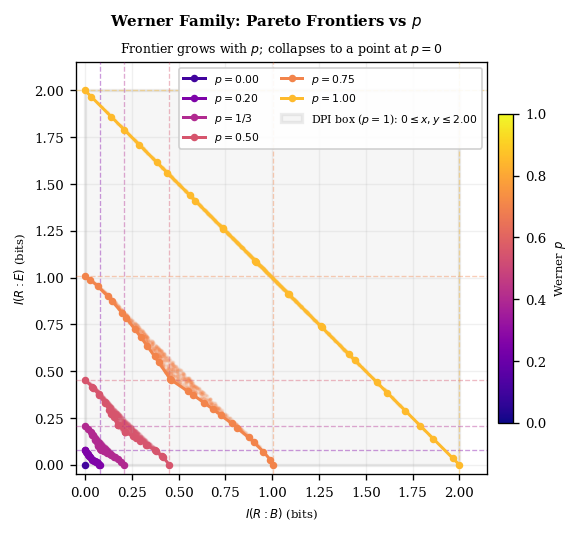

Part 1 · Figure 2 done.


In [10]:
# ── Figure 2: Werner family — multiple frontiers ──────────────────────────────
# DPI box is per-state and would overlap if overlaid on one axis,
# so instead we draw the DPI bound as a vertical/horizontal line
# for the p=1 (Bell) case, which sets the widest box.

werner_ps     = [0.0, 0.20, 1/3, 0.50, 0.75, 1.0]
werner_colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(werner_ps)))

fig2, ax2 = plt.subplots(1, 1, figsize=FIG['single'])
fig2.suptitle(r'Werner Family: Pareto Frontiers vs $p$',
              fontsize=9, fontweight='bold')

for p, col in zip(werner_ps, werner_colors):
    rho    = werner(p)
    nsamp  = 300 if p < 0.05 else 800
    npts   = 6   if p < 0.05 else 12
    print(f'\n>>> Werner p={p:.3f}')
    info     = compute_state_info(rho)
    I_RA_p   = info['I_RA']
    pts      = sample_kak_isometries(rho, n_samples=nsamp, seed=42)
    frontier = pareto_frontier(rho, n_points=npts, n_restarts=5,
                               n_extreme_restarts=30, seed=42)
    label = f'$p={p:.2f}$' if p != 1/3 else r'$p=1/3$'
    ax2.plot(frontier[:, 0], frontier[:, 1],
             color=col, lw=1.8, marker='o', ms=3.5,
             zorder=5, label=label)
    ax2.scatter(pts[:, 0], pts[:, 1],
                s=2, alpha=0.12, c=[col], rasterized=True, zorder=1)
    # Draw DPI bound lines for each p value (faint, matching colour)
    if I_RA_p > 1e-4:
        ax2.axvline(I_RA_p, color=col, lw=0.8, ls='--', alpha=0.4, zorder=3)
        ax2.axhline(I_RA_p, color=col, lw=0.8, ls='--', alpha=0.4, zorder=3)

# Highlight the p=1 (Bell) DPI box explicitly
I_RA_bell = compute_state_info(werner(1.0))['I_RA']
rect_bell = mpatches.FancyBboxPatch(
    (0, 0), I_RA_bell, I_RA_bell,
    boxstyle="square,pad=0",
    facecolor=C['dpi_fill'], edgecolor=C['dpi'],
    alpha=0.10, linewidth=2.0, zorder=0,
    label=f'DPI box ($p=1$): $0\\leq x,y\\leq{I_RA_bell:.2f}$')
ax2.add_patch(rect_bell)

ax2.set_xlim(-0.05, 2.15)
ax2.set_ylim(-0.05, 2.15)
ax2.set_aspect('equal')
ax2.set_xlabel('$I(R:B)$ (bits)', fontsize=7)
ax2.set_ylabel('$I(R:E)$ (bits)', fontsize=7)
ax2.set_title('Frontier grows with $p$; collapses to a point at $p=0$',
              fontsize=7.5)
ax2.legend(fontsize=6.5, loc='upper right', framealpha=0.9, ncol=2)
sm = plt.cm.ScalarMappable(cmap='plasma',
                            norm=plt.Normalize(vmin=0.0, vmax=1.0))
sm.set_array([])
cbar = fig2.colorbar(sm, ax=ax2, shrink=0.75, pad=0.02)
cbar.set_label('Werner $p$', fontsize=7)

save_figure(fig2, 'p1_fig2_werner_frontiers')
plt.show()
print('Part 1 · Figure 2 done.')


>>> Depolarising on $|\Phi^+\rangle$ ($p=0.4$)
  S(R)=1.0000  S(RA)=1.3568  I(R:A)=0.6432
  I_c(A→R) = 0.0000  →  Buscemi LB = 2·I_c = 0.0000  [exact]
  D(R|A)=0.3651  D(A|R)=0.3651  min_D=0.3651
  SSA_upper  = 1.6432  [exact]
  discord_ub = 0.7303  [conjecture]
  C_hide_lb  = 0.5561  [conjecture]
  hidden_env = False
  Sampling 1500 isometries...
  Computing Pareto frontier...
    IE_max=0.6432  IB_max=0.6432

>>> Dephasing on $|\Phi^+\rangle$ ($p=0.5$)
  S(R)=1.0000  S(RA)=1.0000  I(R:A)=1.0000
  I_c(A→R) = 0.0000  →  Buscemi LB = 2·I_c = 0.0000  [exact]
  D(R|A)=0.0000  D(A|R)=0.0000  min_D=0.0000
  SSA_upper  = 2.0000  [exact]
  discord_ub = 2.0000  [conjecture]
  C_hide_lb  = 0.0000  [conjecture]
  hidden_env = False
  Sampling 1500 isometries...
  Computing Pareto frontier...
    IE_max=1.0000  IB_max=1.0000

>>> Bit-flip on $|\Phi^+\rangle$ ($p=0.4$)
  S(R)=1.0000  S(RA)=0.9710  I(R:A)=1.0290
  I_c(A→R) = 0.0290  →  Buscemi LB = 2·I_c = 0.0581  [exact]
  D(R|A)=0.0290  D(A|R)=0

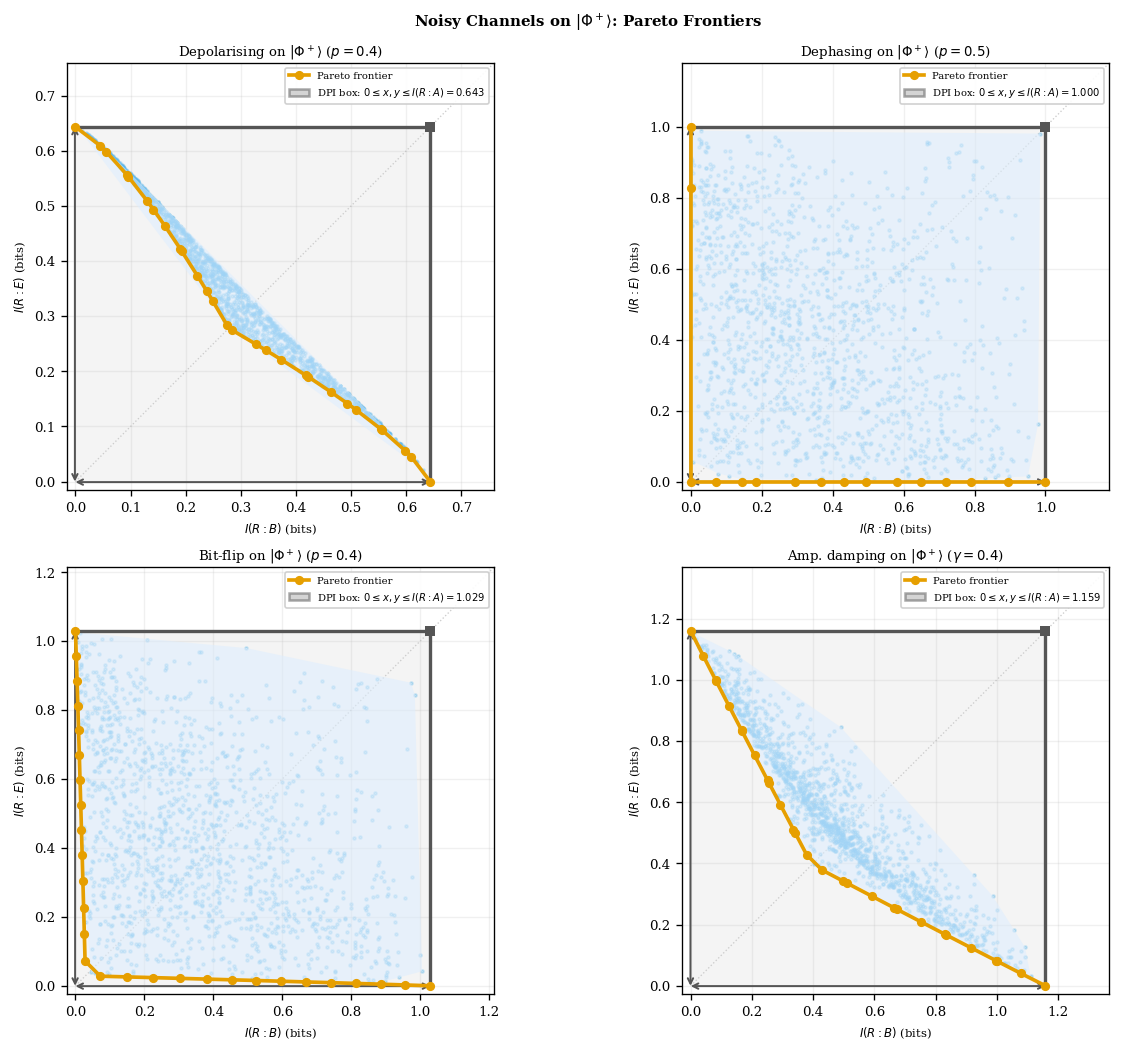

Part 1 · Figure 3 done.


In [11]:
# ── Figure 3: Noisy channels — frontiers only (with DPI box) ─────────────────
states_fig3 = [
    (depolarised(dm_phi_plus, 0.4),
     r'Depolarising on $|\Phi^+\rangle$ ($p=0.4$)',         1500),
    (dephasing_channel(dm_phi_plus, 0.5),
     r'Dephasing on $|\Phi^+\rangle$ ($p=0.5$)',            1500),
    (bit_flip_channel(dm_phi_plus, 0.4),
     r'Bit-flip on $|\Phi^+\rangle$ ($p=0.4$)',             1500),
    (amplitude_damping_channel(dm_phi_plus, 0.4),
     r'Amp. damping on $|\Phi^+\rangle$ ($\gamma=0.4$)',    1500),
]

fig3, axes3 = plt.subplots(2, 2, figsize=FIG['full_2x2'])
fig3.suptitle(r'Noisy Channels on $|\Phi^+\rangle$: Pareto Frontiers',
              fontsize=9, fontweight='bold')

results_p1_fig3 = []
for ax, (rho, name, nsamp) in zip(axes3.flat, states_fig3):
    print(f'\n>>> {name}')
    res = draw_pareto_only(ax, rho, name,
                           n_samples=nsamp,
                           n_pareto_points=14,
                           n_pareto_restarts=6,
                           n_extreme_restarts=40,
                           seed=42, verbose=True)
    results_p1_fig3.append(res)

# add_panel_labels(axes3)
save_figure(fig3, 'p1_fig3_noisy_frontiers')
plt.show()
print('Part 1 · Figure 3 done.')


>>> Bell mixture p=0.00
    IE_max=2.0000  IB_max=2.0000

>>> Bell mixture p=0.25
    IE_max=1.1887  IB_max=1.1887

>>> Bell mixture p=0.50
    IE_max=1.0000  IB_max=1.0000

>>> Bell mixture p=0.75
    IE_max=1.1887  IB_max=1.1887

>>> Bell mixture p=1.00
    IE_max=2.0000  IB_max=2.0000
  Saved p1_fig4_bell_mixture_frontiers.pdf / .png


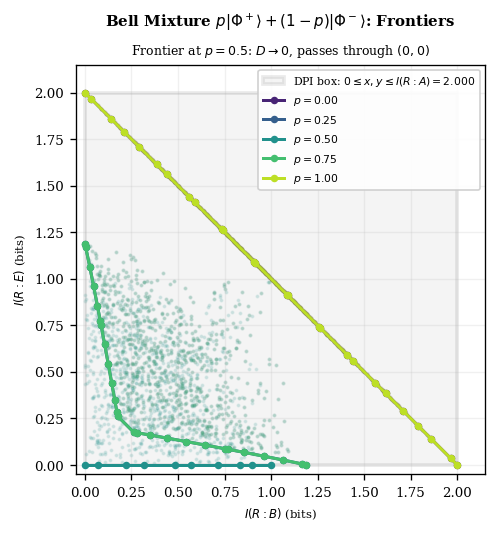

Part 1 · Figure 4 done.


In [12]:
# ── Figure 4: Bell mixture ────────────────────────────────────────────────────
bell_mixture_ps     = [0.0, 0.25, 0.50, 0.75, 1.0]
bell_mixture_colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(bell_mixture_ps)))

fig4, ax4 = plt.subplots(1, 1, figsize=FIG['single'])
fig4.suptitle(
    r'Bell Mixture $p|\Phi^+\rangle+(1-p)|\Phi^-\rangle$: Frontiers',
    fontsize=9, fontweight='bold')

# Draw the shared DPI box (all Bell mixtures have same I(R:A))
I_RA_bm = compute_state_info(bell_mixture(1.0))['I_RA']
rect_bm = mpatches.FancyBboxPatch(
    (0, 0), I_RA_bm, I_RA_bm,
    boxstyle="square,pad=0",
    facecolor=C['dpi_fill'], edgecolor=C['dpi'],
    alpha=0.12, linewidth=2.2, zorder=0,
    label=f'DPI box: $0\\leq x,y\\leq I(R:A)={I_RA_bm:.3f}$')
ax4.add_patch(rect_bm)

for p, col in zip(bell_mixture_ps, bell_mixture_colors):
    rho      = bell_mixture(p)
    npts     = 8 if abs(p - 0.5) < 0.05 else 12
    print(f'\n>>> Bell mixture p={p:.2f}')
    pts      = sample_kak_isometries(rho, n_samples=800, seed=42)
    frontier = pareto_frontier(rho, n_points=npts, n_restarts=5,
                               n_extreme_restarts=30, seed=42)
    ax4.plot(frontier[:, 0], frontier[:, 1],
             color=col, lw=1.8, marker='o', ms=3.5,
             zorder=5, label=f'$p={p:.2f}$')
    ax4.scatter(pts[:, 0], pts[:, 1],
                s=2, alpha=0.12, c=[col], rasterized=True, zorder=1)

ax4.set_xlim(-0.05, 2.15)
ax4.set_ylim(-0.05, 2.15)
ax4.set_aspect('equal')
ax4.set_xlabel('$I(R:B)$ (bits)', fontsize=7)
ax4.set_ylabel('$I(R:E)$ (bits)', fontsize=7)
ax4.set_title(r'Frontier at $p=0.5$: $D\to 0$, passes through $(0,0)$',
              fontsize=7.5)
ax4.legend(fontsize=6.5, loc='upper right', framealpha=0.9)

save_figure(fig4, 'p1_fig4_bell_mixture_frontiers')
plt.show()
print('Part 1 · Figure 4 done.')